
<div style="text-align: center;">
  <img src="finger-pressing-red-icon.jpg"" width="630" height="630">
</div>





# Domain Analysis – Telecom Customer Churn Prediction

  * Client: No‑Churn Telecom
  * Project Ref: PRCL-0017 – Telecom Churn ML
  * team-id:-PTID-CDS-NOV-25-3358
  * Model Performance: ~95% Accuracy

## PRCL-0017 Customer Churn Busine…

## 1. Business Domain Overview (Telecom Industry)

* The telecom industry is highly competitive, with customers having low switching costs and multiple service providers offering similar pricing and plans. Customer retention is therefore a critical business challenge, as acquiring new customers is significantly more expensive than retaining existing ones.

* No-Churn Telecom, an established European telecom operator, is currently facing a churn rate exceeding 10%, despite offering reduced tariffs and promotional plans. This indicates that pricing alone is insufficient to prevent customer attrition and that behavioral and service-related factors play a major role in churn decisions.

* PRCL-0017 Customer Churn Busine…

## 2. Problem Statement

* Customer churn directly impacts:

* Revenue loss

* Increased customer acquisition costs

* Reduced market share

* The key challenge for No-Churn Telecom is to:

* Identify customers likely to churn

* Understand the drivers behind churn

* Take proactive retention actions before customers leave

* Traditional rule-based systems are ineffective due to the high dimensionality and complex interactions between customer usage, service quality, and support experience.

## 3. Business Objective

* The objective of this project is to leverage Machine Learning to support No-Churn Telecom in:

* Identifying key variables influencing churn

* Predicting customer churn accurately

* Generating a new target variable CHURN-FLAG (YES/NO)

* Assigning churn risk scores to prioritize retention campaigns



## 4. Data Understanding & Domain Relevance

* The dataset consists of 4,617 customer records extracted from a production SQL database, representing real operational telecom data.

* Key domain-relevant variable groups:

* Customer Profile:
* State, Account Length, Area Code

* Service Plans:
International Plan, Voice Mail Plan

* Usage Behavior:
Day, Evening, Night & International Minutes and Calls

* Revenue Indicators:
* Call Charges across time slots

* Customer Experience:
* Number of Customer Service Calls

* Target Variable:
* Churn → transformed into CHURN-FLAG (1 = Yes, 0 = No)

* These variables collectively capture customer value, satisfaction, and engagement, which are critical churn indicators in the telecom domain.



## 5. Analytical Approach (Domain-Driven)

* A supervised classification approach was adopted:

* Data cleaning and encoding of categorical variables

* Feature scaling and transformation

* Model training using classification algorithms

* Evaluation using Accuracy, Precision, Recall, and F1-Score

* The final model achieved ~95% accuracy, indicating strong predictive capability and robustness in identifying churn-prone customers.

* From a domain perspective, this level of accuracy is highly actionable, enabling business teams to trust and operationalize the model.

## 6. Key Business Insights (Domain Interpretation)

* From telecom churn behavior patterns:

* Customers with international plans show higher churn probability due to pricing sensitivity

* Frequent customer service calls strongly correlate with dissatisfaction

* High day-time usage charges without perceived value increase churn risk

* Long-tenure customers are generally less likely to churn, but service issues override loyalty

* These insights help the business move from reactive retention to predictive intervention.

## 7. Business Value Delivered

### This solution enables No-Churn Telecom to:

 * Target only high-risk customers, reducing campaign costs

 * Run focused email & offer-based retention campaigns

 * Prioritize customer care tickets for churn-risk users

 * Reduce revenue leakage and improve customer lifetime value

 * The introduction of CHURN-FLAG allows seamless integration with CRM and marketing automation systems.



In [83]:
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import *
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.svm import SVC
import warnings
import joblib

In [2]:
warnings.filterwarnings('ignore')

In [3]:



# Database connection
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team3",
    password="DM!$!Team!27@9!20&",
    database="project_telecom"
)

# SQL Query
query = "SELECT * FROM telecom_churn_data"

# Load data into DataFrame
df = pd.read_sql(query, conn)

# Save as CSV
df.to_csv("telecom_churn_data.csv", index=False)

print("Data successfully downloaded!")


Data successfully downloaded!


In [4]:
df

,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,...,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.3,3,False.
4613,NM,177,408,343-6820,no,yes,29,189,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [5]:
df.shape

(4617, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   columns1   4617 non-null   object
 1   columns2   4617 non-null   object
 2   columns3   4617 non-null   object
 3   columns4   4617 non-null   object
 4   columns5   4617 non-null   object
 5   columns6   4617 non-null   object
 6   columns7   4617 non-null   object
 7   columns8   4617 non-null   object
 8   columns9   4617 non-null   object
 9   columns10  4617 non-null   object
 10  columns11  4617 non-null   object
 11  columns12  4617 non-null   object
 12  columns13  4617 non-null   object
 13  columns14  4617 non-null   object
 14  columns15  4617 non-null   object
 15  columns16  4617 non-null   object
 16  columns17  4617 non-null   object
 17  columns18  4617 non-null   object
 18  columns19  4617 non-null   object
 19  columns20  4617 non-null   object
 20  columns21  4617 non-null   obj

In [7]:
df.columns = [
    "State",
    "Account Length",
    "Area Code",
    "Phone",
    "International Plan",
    "VMail Plan",
    "VMail Message",
    "Day Mins",
    "Day Calls",
    "Day Charge",
    "Eve Mins",
    "Eve Calls",
    "Eve Charge",
    "Night Mins",
    "Night Calls",
    "Night Charge",
    "International Mins",
    "International Calls",
    "International Charge",
    "CustServ Calls",
    "Churn"
]


In [8]:
df

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.3,3,False.
4613,NM,177,408,343-6820,no,yes,29,189,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [9]:
int_cols = [
    "Account Length", "Area Code", "VMail Message",
    "Day Calls", "Eve Calls", "Night Calls",
    "International Calls", "CustServ Calls"
]

for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("int64")


In [10]:
float_cols = [
    "Day Mins", "Day Charge",
    "Eve Mins", "Eve Charge",
    "Night Mins", "Night Charge",
    "International Mins", "International Charge"
]

for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [11]:
df["International Plan"] = df["International Plan"].str.strip()
df["VMail Plan"] = df["VMail Plan"].str.strip()
df["Churn"] = df["Churn"].str.strip()


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 4617 non-null   object 
 1   Account Length        4617 non-null   int64  
 2   Area Code             4617 non-null   int64  
 3   Phone                 4617 non-null   object 
 4   International Plan    4617 non-null   object 
 5   VMail Plan            4617 non-null   object 
 6   VMail Message         4617 non-null   int64  
 7   Day Mins              4617 non-null   float64
 8   Day Calls             4617 non-null   int64  
 9   Day Charge            4617 non-null   float64
 10  Eve Mins              4617 non-null   float64
 11  Eve Calls             4617 non-null   int64  
 12  Eve Charge            4617 non-null   float64
 13  Night Mins            4617 non-null   float64
 14  Night Calls           4617 non-null   int64  
 15  Night Charge         

In [13]:
df.describe()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls
count,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000
mean,100.645224,437.046350,7.849903,180.447152,100.054364,30.676576,200.429088,100.179770,17.036703,200.623933,99.944120,9.028185,10.279294,4.433831,2.775926,1.567035
std,39.597194,42.288212,13.592333,53.983540,19.883027,9.177145,50.557001,19.821314,4.297332,50.543616,19.935053,2.274488,2.757361,2.457615,0.744413,1.307019
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,12.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,165.900000,87.000000,14.100000,167.100000,87.000000,7.520000,8.600000,3.000000,2.320000,1.000000
50%,100.000000,415.000000,0.000000,180.000000,100.000000,30.600000,200.800000,101.000000,17.070000,200.800000,100.000000,9.040000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,17.000000,216.800000,113.000000,36.860000,234.000000,114.000000,19.890000,234.900000,113.000000,10.570000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [14]:
df.head()

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [15]:
df.tail()

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.
4616,IN,140,415,409-6884,no,no,0,204.7,100,34.80,...,107,10.78,202.8,115,9.13,12.1,4,3.27,2,False.


In [16]:
df["Churn_Flag1"] = df["Churn"].map({"True.": 1, "False.": 0})


In [17]:
df["International Plan1"] = df["International Plan"].map({"yes": 1, "no": 0})
df

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn,Churn_Flag1,International Plan1
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,244.7,91,11.01,10.0,3,2.70,1,False.,0,0
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,254.4,103,11.45,13.7,3,3.70,1,False.,0,0
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,162.6,104,7.32,12.2,5,3.29,0,False.,0,0
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,196.9,89,8.86,6.6,7,1.78,2,False.,0,1
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,186.9,121,8.41,10.1,3,2.73,3,False.,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,...,158.6,122,7.14,8.5,6,2.30,3,False.,0,0
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,...,163.6,116,7.36,15.7,1,4.24,3,False.,0,0
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,200.9,91,9.04,13.0,3,3.51,1,False.,0,0
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,165.5,96,7.45,14.3,3,3.86,0,False.,0,0


In [18]:
df["VMail Plan1"] = df["VMail Plan"].map({"yes": 1, "no": 0})

In [19]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")


In [20]:
encoded = ohe.fit_transform(df[["State"]])


In [21]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["State"])
)


In [22]:
df = pd.concat([df.drop("State", axis=1), encoded_df], axis=1)


In [23]:
OneHotEncoder(sparse_output=False)


OneHotEncoder(sparse_output=False)

In [24]:
df

,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4613,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4614,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4615,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
df.head()
df.shape


(4617, 74)

In [26]:
cols = df.select_dtypes(include="float").columns
df[cols] = df[cols].astype(int)


In [27]:
df.columns

Index(['Account Length', 'Area Code', 'Phone', 'International Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'International Mins', 'International Calls',
       'International Charge', 'CustServ Calls', 'Churn', 'Churn_Flag1',
       'International Plan1', 'VMail Plan1', 'State_AK', 'State_AL',
       'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DC',
       'State_DE', 'State_FL', 'State_GA', 'State_HI', 'State_IA', 'State_ID',
       'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA',
       'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS',
       'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ',
       'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR',
       'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX',
       'State_UT

In [28]:
df.to_csv("telecom_churn_cleaned_final.csv", index=False)


In [29]:
df

,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,382-4657,no,yes,25,265,110,45,197,...,0,0,0,0,0,0,0,0,0,0
1,107,415,371-7191,no,yes,26,161,123,27,195,...,0,0,0,0,0,0,0,0,0,0
2,137,415,358-1921,no,no,0,243,114,41,121,...,0,0,0,0,0,0,0,0,0,0
3,84,408,375-9999,yes,no,0,299,71,50,61,...,0,0,0,0,0,0,0,0,0,0
4,75,415,330-6626,yes,no,0,166,113,28,148,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,345-7512,no,yes,25,144,81,24,187,...,0,0,0,0,0,0,0,0,0,0
4613,177,408,343-6820,no,yes,29,189,91,32,303,...,0,0,0,0,0,0,0,0,0,0
4614,67,408,338-4794,no,yes,33,127,126,21,296,...,0,0,0,0,0,1,0,0,0,0
4615,98,415,355-8388,no,yes,23,168,98,28,226,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.drop(columns=["Churn","International Plan","VMail Plan"], inplace=True)


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 71 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Account Length        4617 non-null   int64 
 1   Area Code             4617 non-null   int64 
 2   Phone                 4617 non-null   object
 3   VMail Message         4617 non-null   int64 
 4   Day Mins              4617 non-null   int64 
 5   Day Calls             4617 non-null   int64 
 6   Day Charge            4617 non-null   int64 
 7   Eve Mins              4617 non-null   int64 
 8   Eve Calls             4617 non-null   int64 
 9   Eve Charge            4617 non-null   int64 
 10  Night Mins            4617 non-null   int64 
 11  Night Calls           4617 non-null   int64 
 12  Night Charge          4617 non-null   int64 
 13  International Mins    4617 non-null   int64 
 14  International Calls   4617 non-null   int64 
 15  International Charge  4617 non-null   

In [32]:
df.isnull().sum()

Account Length    0
Area Code         0
Phone             0
VMail Message     0
Day Mins          0
                 ..
State_VT          0
State_WA          0
State_WI          0
State_WV          0
State_WY          0
Length: 71, dtype: int64

In [33]:
df.shape

(4617, 71)

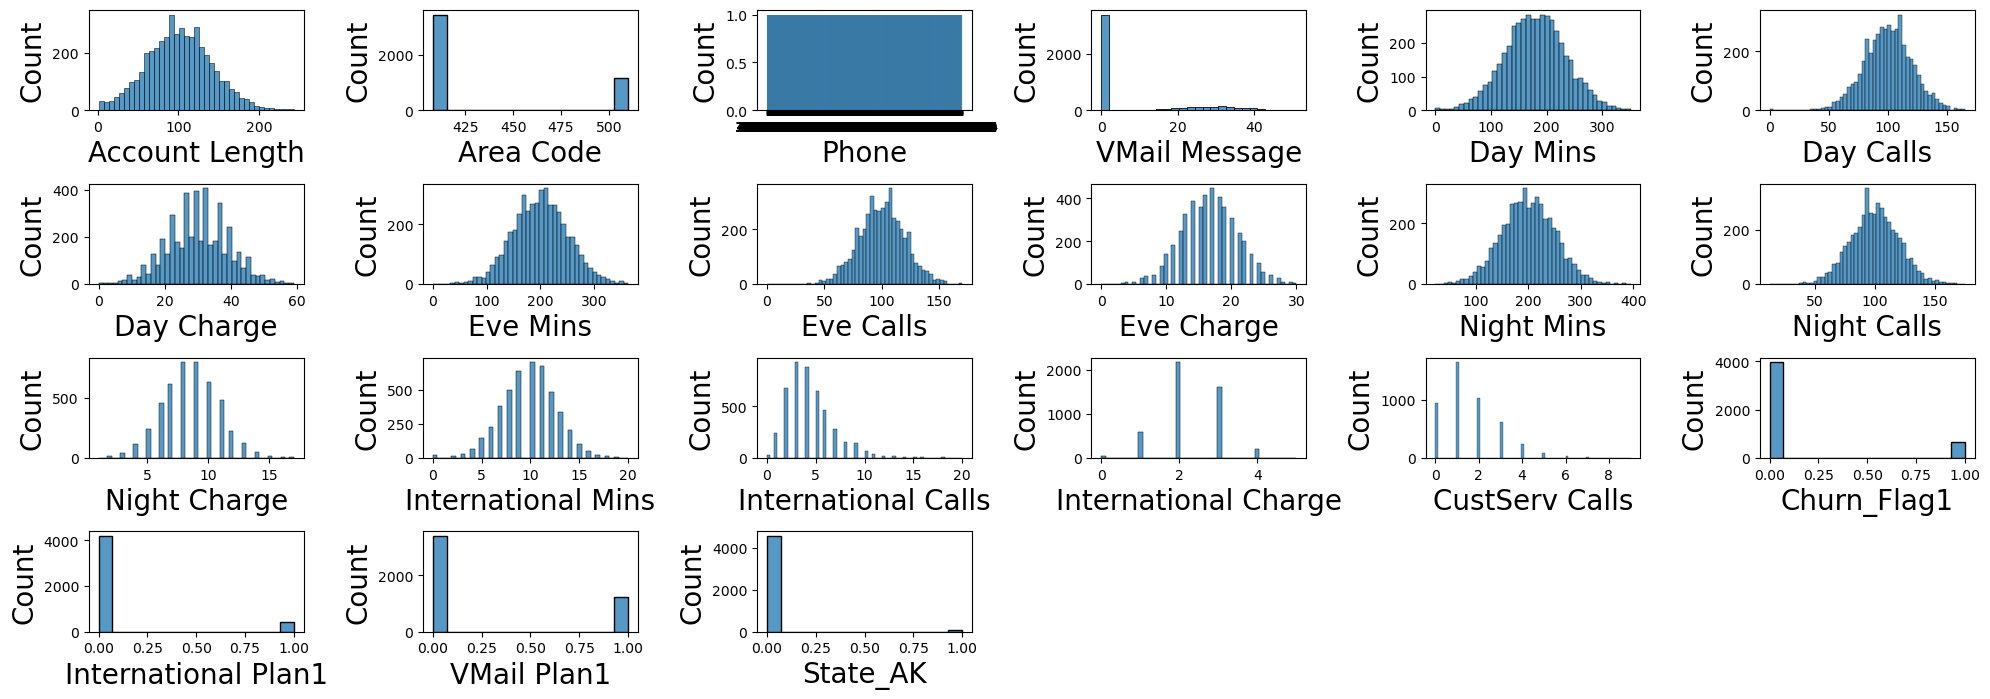

In [34]:
plt.figure(figsize=(20,10))
pn=1
for i in df:
    if pn<=21:
        ax=plt.subplot(6,6,pn)
        sns.histplot(x=df[i])
        plt.xlabel(i,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    pn+=1
plt.tight_layout()
plt.show()    


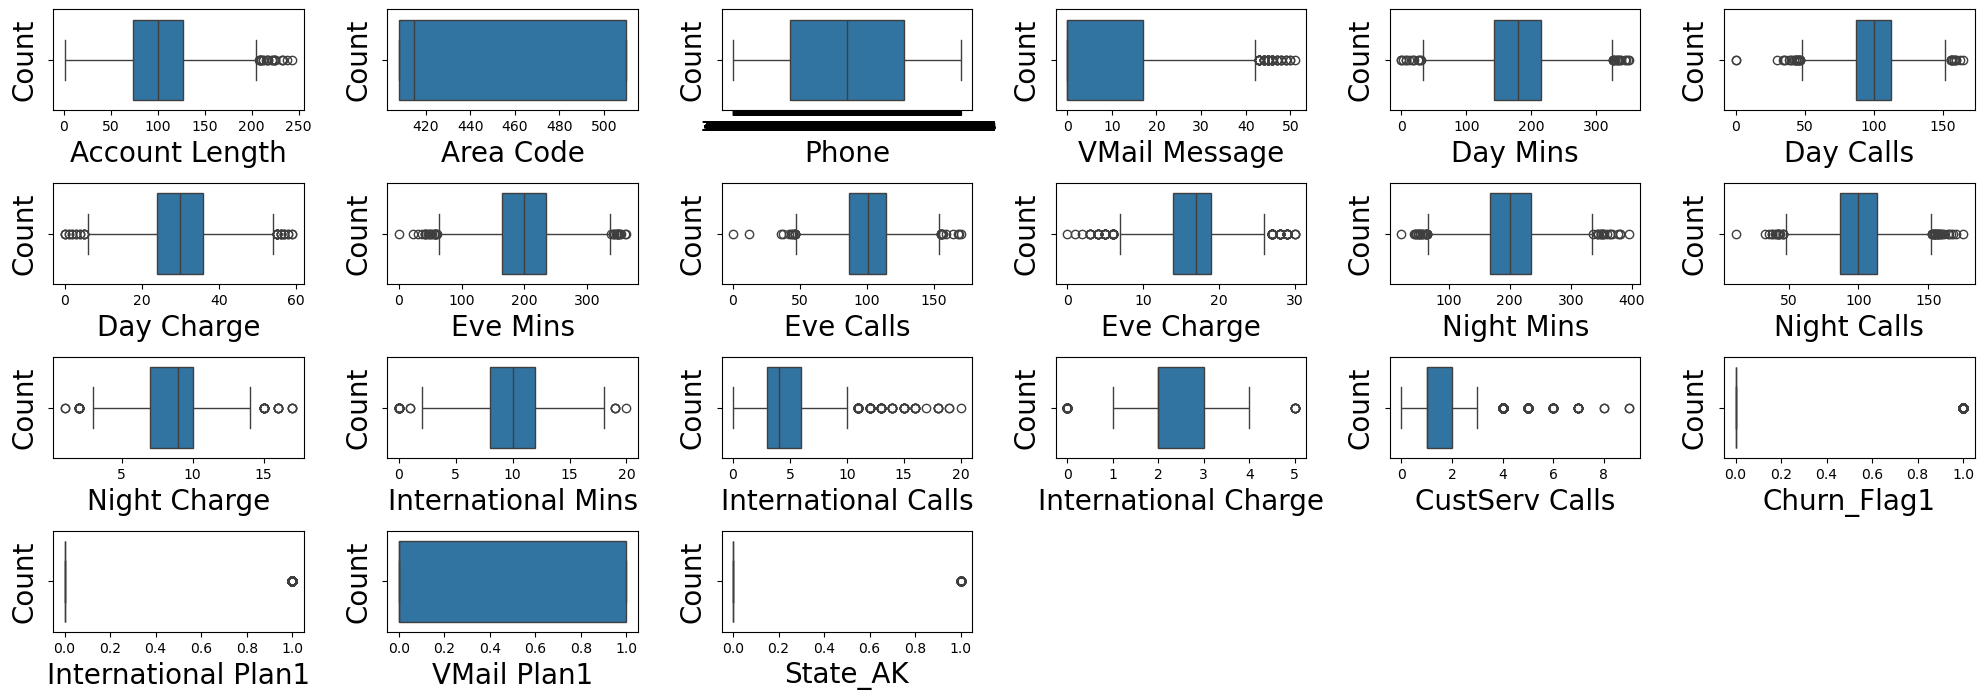

In [35]:
plt.figure(figsize=(20,10))
pn=1
for i in df:
    if pn<=21:
        ax=plt.subplot(6,6,pn)
        sns.boxplot(x=df[i])
        plt.xlabel(i,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    pn+=1
plt.tight_layout()
plt.show()    


In [36]:
cols = [
    "Day Mins", "Day Charge",
    "Eve Mins", "Eve Charge",
    "Night Mins", "Night Charge",
    "International Mins", "International Charge"
]

df[cols] = (
    df[cols]
    .fillna(0)
    .astype("float64")
    .round(0)
    .astype("int64")
)


In [37]:
churn_counts = df['Churn_Flag1'].value_counts()
churn_counts

Churn_Flag1
0    3961
1     656
Name: count, dtype: int64

In [38]:
labels = ['Not Churned', 'Churned']
colors = ['skyblue', 'salmon']

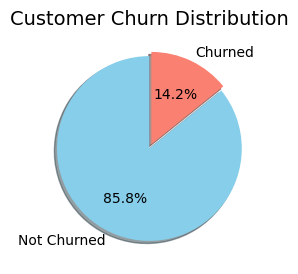

In [39]:

plt.figure(figsize=(3,3))
plt.pie(
    churn_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True,
    explode=(0, 0.05)
)

plt.title('Customer Churn Distribution', fontsize=14)
plt.show()


In [84]:
le=LabelEncoder()

df["Phone"]=le.fit_transform(df["Phone"])


In [85]:
df

,Account Length,Area Code,Phone,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,2637,25,265,110,45,197,99,16,...,0,0,0,0,0,0,0,0,0,0
1,107,415,2132,26,161,123,27,195,103,16,...,0,0,0,0,0,0,0,0,0,0
2,137,415,1509,0,243,114,41,121,110,10,...,0,0,0,0,0,0,0,0,0,0
3,84,408,2326,0,299,71,50,61,88,5,...,0,0,0,0,0,0,0,0,0,0
4,75,415,150,0,166,113,28,148,122,12,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,890,25,144,81,24,187,112,15,...,0,0,0,0,0,0,0,0,0,0
4613,177,408,795,29,189,91,32,303,96,25,...,0,0,0,0,0,0,0,0,0,0
4614,67,408,533,33,127,126,21,296,129,25,...,0,0,0,0,0,1,0,0,0,0
4615,98,415,1406,23,168,98,28,226,117,19,...,0,0,0,0,0,0,0,0,0,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 71 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Account Length        4617 non-null   int64
 1   Area Code             4617 non-null   int64
 2   Phone                 4617 non-null   int64
 3   VMail Message         4617 non-null   int64
 4   Day Mins              4617 non-null   int64
 5   Day Calls             4617 non-null   int64
 6   Day Charge            4617 non-null   int64
 7   Eve Mins              4617 non-null   int64
 8   Eve Calls             4617 non-null   int64
 9   Eve Charge            4617 non-null   int64
 10  Night Mins            4617 non-null   int64
 11  Night Calls           4617 non-null   int64
 12  Night Charge          4617 non-null   int64
 13  International Mins    4617 non-null   int64
 14  International Calls   4617 non-null   int64
 15  International Charge  4617 non-null   int64
 16  CustSe

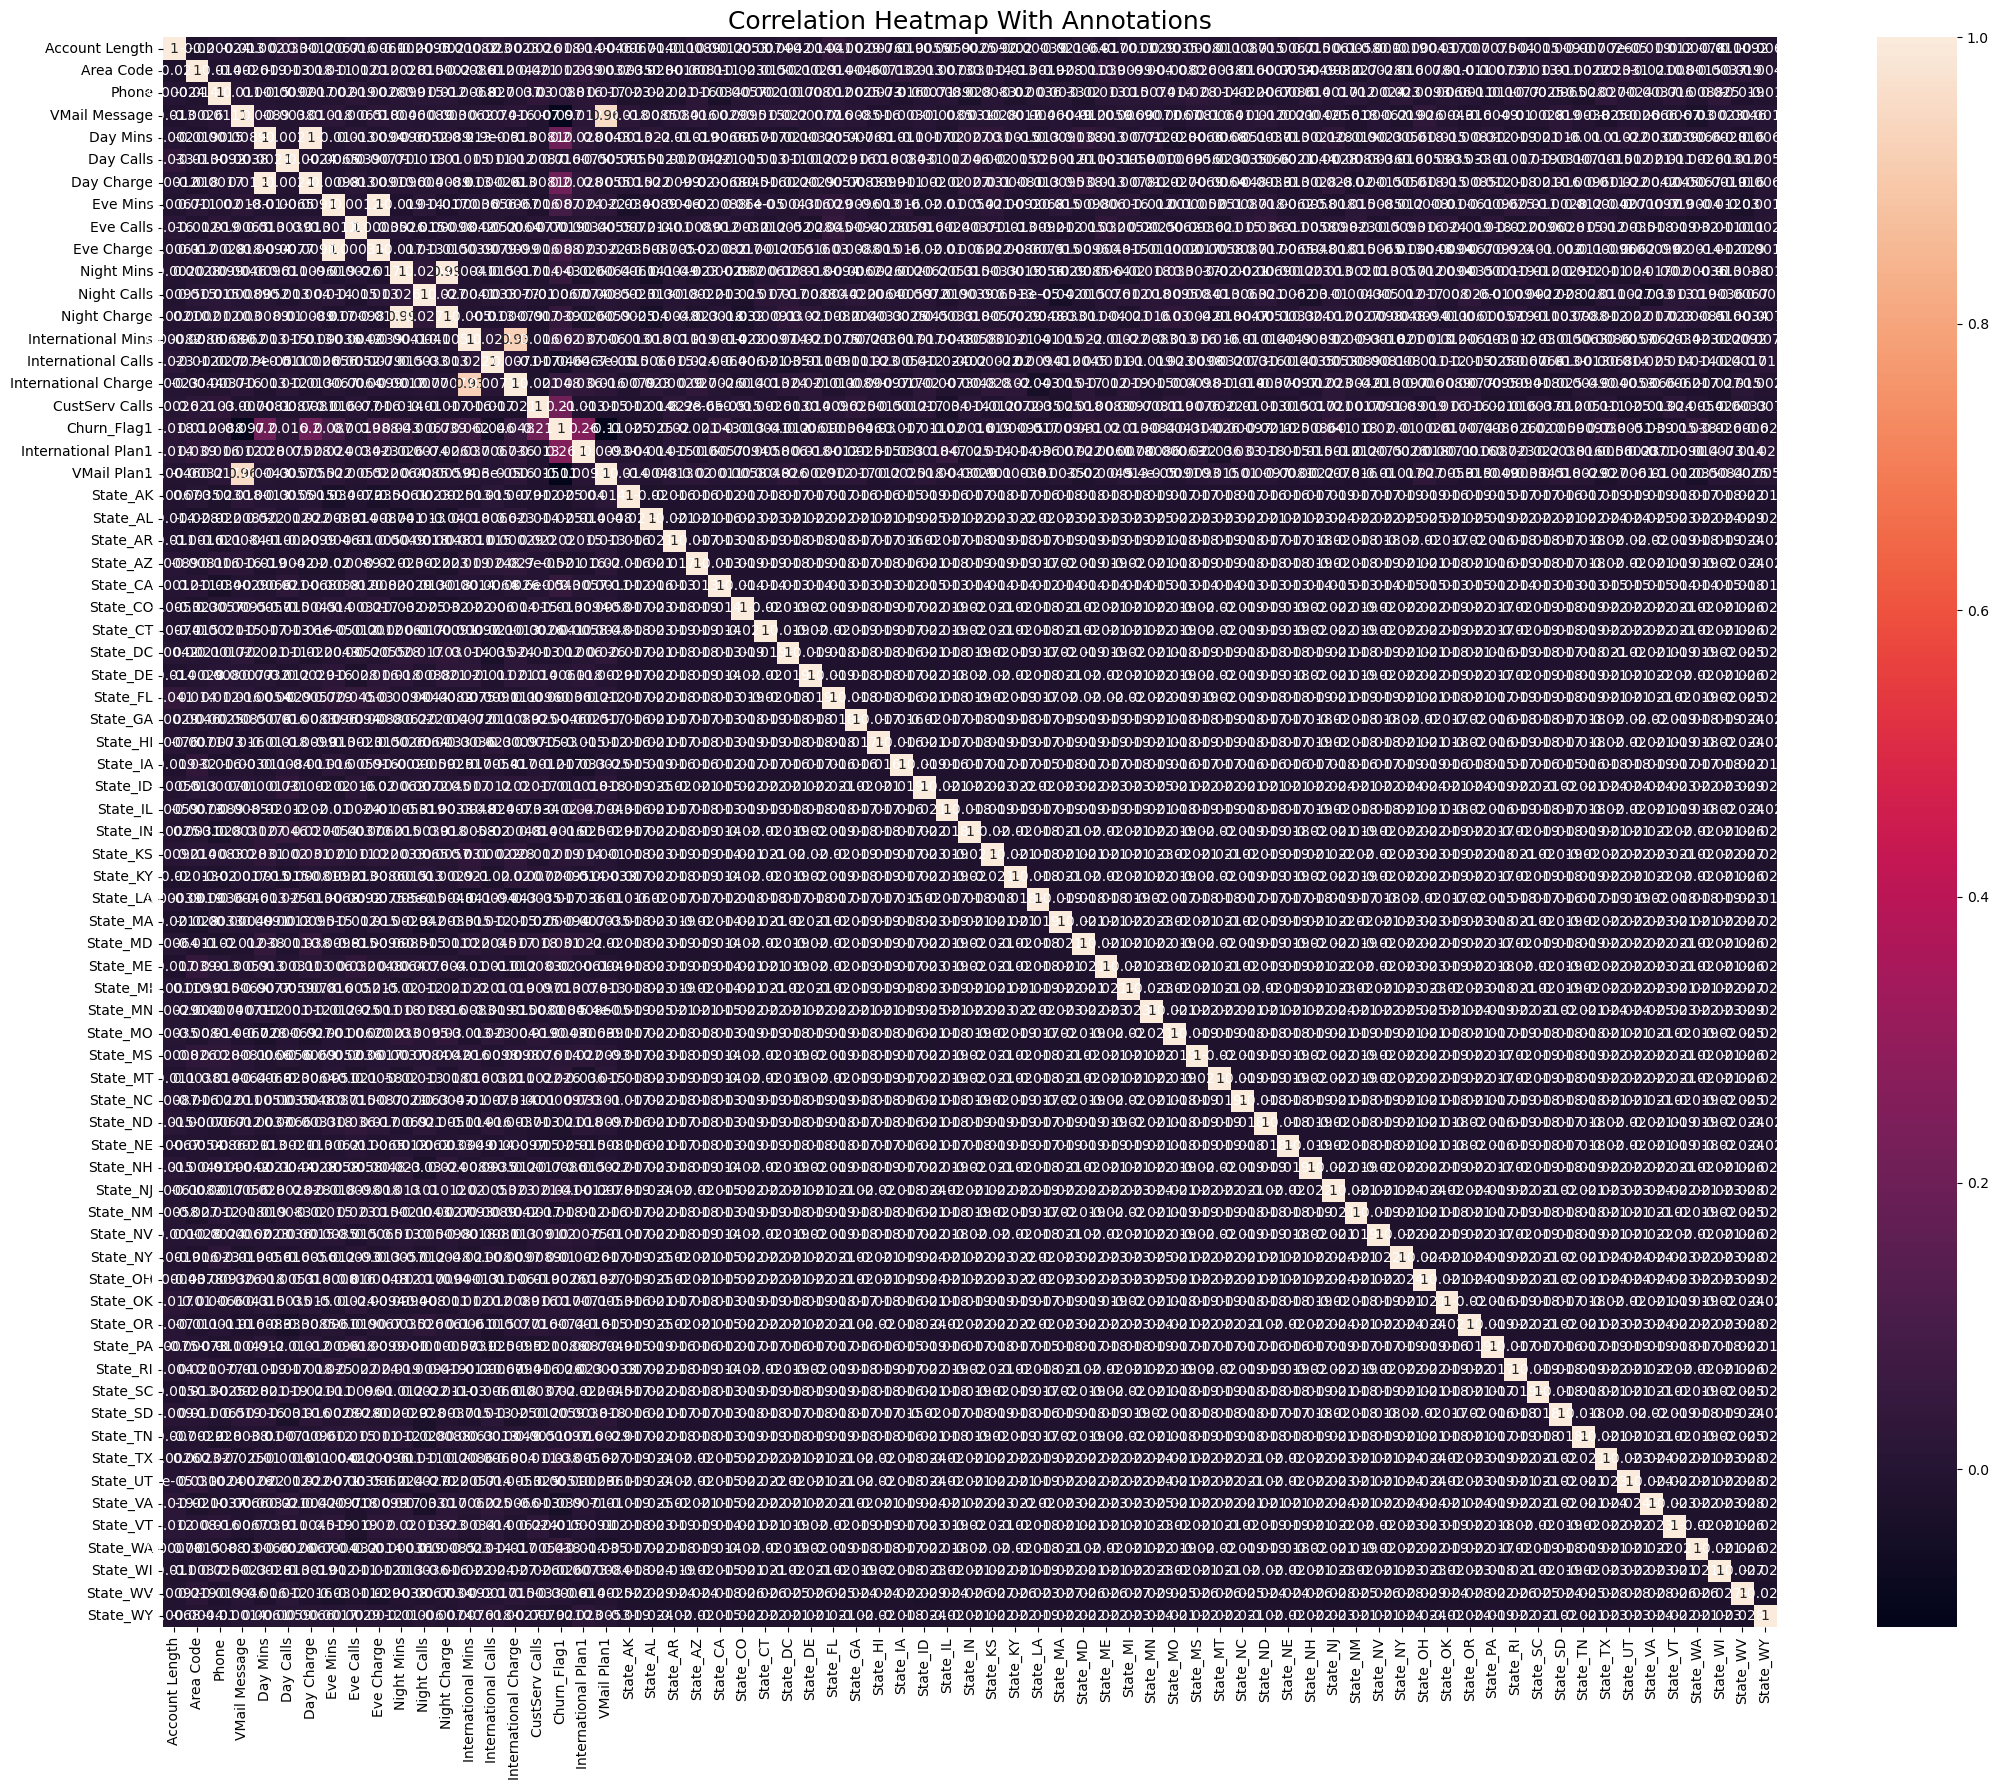

In [87]:
plt.figure(figsize=(22, 18))  
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,        
   linecolor="gray"
)

plt.title("Correlation Heatmap With Annotations", fontsize=18)
plt.tight_layout()
plt.show()

In [88]:
df

,Account Length,Area Code,Phone,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,2637,25,265,110,45,197,99,16,...,0,0,0,0,0,0,0,0,0,0
1,107,415,2132,26,161,123,27,195,103,16,...,0,0,0,0,0,0,0,0,0,0
2,137,415,1509,0,243,114,41,121,110,10,...,0,0,0,0,0,0,0,0,0,0
3,84,408,2326,0,299,71,50,61,88,5,...,0,0,0,0,0,0,0,0,0,0
4,75,415,150,0,166,113,28,148,122,12,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,890,25,144,81,24,187,112,15,...,0,0,0,0,0,0,0,0,0,0
4613,177,408,795,29,189,91,32,303,96,25,...,0,0,0,0,0,0,0,0,0,0
4614,67,408,533,33,127,126,21,296,129,25,...,0,0,0,0,0,1,0,0,0,0
4615,98,415,1406,23,168,98,28,226,117,19,...,0,0,0,0,0,0,0,0,0,0


In [89]:

X = df.drop(columns=["Phone",'Churn_Flag1'])

X

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,25,265,110,45,197,99,16,244,...,0,0,0,0,0,0,0,0,0,0
1,107,415,26,161,123,27,195,103,16,254,...,0,0,0,0,0,0,0,0,0,0
2,137,415,0,243,114,41,121,110,10,162,...,0,0,0,0,0,0,0,0,0,0
3,84,408,0,299,71,50,61,88,5,196,...,0,0,0,0,0,0,0,0,0,0
4,75,415,0,166,113,28,148,122,12,186,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57,510,25,144,81,24,187,112,15,158,...,0,0,0,0,0,0,0,0,0,0
4613,177,408,29,189,91,32,303,96,25,163,...,0,0,0,0,0,0,0,0,0,0
4614,67,408,33,127,126,21,296,129,25,200,...,0,0,0,0,0,1,0,0,0,0
4615,98,415,23,168,98,28,226,117,19,165,...,0,0,0,0,0,0,0,0,0,0


In [90]:
y=df["Churn_Flag1"]

In [91]:
y

0       0
1       0
2       0
3       0
4       0
       ..
4612    0
4613    0
4614    0
4615    0
4616    0
Name: Churn_Flag1, Length: 4617, dtype: int64

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [94]:
from imblearn.over_sampling import SMOTE


In [95]:
sm=SMOTE(random_state=42)

In [96]:
X_train_re,y_train_re=sm.fit_resample(X_train_scaled,y_train)

In [97]:
lo=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
lo.fit(X_train_re,y_train_re)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [98]:
param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],  
    "class_weight": ["balanced"]
}

In [99]:
grid = GridSearchCV(
    estimator=lo,
    param_grid=param_grid,
    scoring="accuracy",  
    verbose=3,
    cv=5,
    n_jobs=-1
)

In [100]:
grid.fit(X_train_re,y_train_re)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 5, 10],
                         'class_weight': ['balanced'], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=3)

In [101]:
y_pred=grid.predict(X_test_scaled)

In [102]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [103]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score,average_precision_score,roc_auc_score

In [104]:
print(confusion_matrix(y_test,y_pred))

[[594 205]
 [ 32  93]]


In [105]:
precision_score(y_test,y_pred)

0.31208053691275167

In [106]:
recall_score(y_test,y_pred)

0.744

In [107]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.74      0.83       799
           1       0.31      0.74      0.44       125

    accuracy                           0.74       924
   macro avg       0.63      0.74      0.64       924
weighted avg       0.86      0.74      0.78       924



In [108]:
dt=DecisionTreeClassifier(max_depth=5,random_state=42)

In [109]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]
}


In [110]:
rs = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_grid,  
    n_iter=150,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)

In [111]:
rs.fit(X_train_re,y_train_re)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(max_depth=5,
                                                    random_state=42),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_samples_leaf': [1, 5, 10, 20],
                                        'min_samples_split': [2, 5, 10, 20]},
                   random_state=42, scoring='f1', verbose=2)

In [112]:
y_pred1=rs.predict(X_test_scaled)

In [113]:
y_proba = rs.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba > 0.4).astype(int)


In [114]:
rs.best_params_

{'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 10,
 'criterion': 'entropy',
 'class_weight': 'balanced'}

In [115]:
rs.best_score_

np.float64(0.9317208241414757)

In [116]:
accuracy_score(y_test,y_pred1)

0.9285714285714286

In [117]:
recall_score(y_test,y_pred1)

0.808

In [118]:
precision_score(y_test,y_pred1)



0.7062937062937062

In [119]:
print(confusion_matrix(y_test,y_pred1))

[[757  42]
 [ 24 101]]


In [120]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       799
           1       0.71      0.81      0.75       125

    accuracy                           0.93       924
   macro avg       0.84      0.88      0.86       924
weighted avg       0.93      0.93      0.93       924



In [121]:
# bac=BaggingClassifier(random_state=42)

In [122]:
bag = BaggingClassifier(
    estimator=dt,
    random_state=42,
    n_jobs=-1
)

In [123]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.6, 0.8, 1.0],
    "estimator__max_depth": [3, 5, 7],
    "estimator__min_samples_split": [2, 10, 20],
    "estimator__min_samples_leaf": [1, 5, 10]
}


In [124]:


rs = RandomizedSearchCV(
    estimator=bag,
    param_distributions=param_grid,
    n_iter=100,
    scoring="f1",      
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rs.fit(X_train_re, y_train_re)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                                                random_state=42),
                                               n_jobs=-1, random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'estimator__max_depth': [3, 5, 7],
                                        'estimator__min_samples_leaf': [1, 5,
                                                                        10],
                                        'estimator__min_samples_split': [2, 10,
                                                                         20],
                                        'max_samples': [0.6, 0.8, 1.0],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='f1', verbose=2)

In [125]:
y_pred=rs.predict(X_test_scaled)

In [126]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       799
           1       0.74      0.81      0.77       125

    accuracy                           0.94       924
   macro avg       0.85      0.88      0.87       924
weighted avg       0.94      0.94      0.94       924



In [127]:
rf=RandomForestClassifier(  n_estimators=50,
    random_state=42,
    n_jobs=-1)

In [128]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}


In [129]:

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=100,
    scoring="accuracy",      
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rs.fit(X_train_re, y_train_re)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_estimators=50, n_jobs=-1,
                                                    random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 7],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 5, 10],
                                        'min_samples_split': [2, 10, 20],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [130]:
rs.best_params_

{'n_estimators': 50,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 7}

In [131]:
y_pred1=rs.predict(X_test_scaled)
# y_proba = rs.predict_proba(X_test)[:, 1]
# y_pred = (y_proba > 0.4).astype(int)

In [132]:
precision_score(y_test,y_pred1)

0.5487804878048781

In [133]:
print(confusion_matrix(y_test,y_pred1))

[[725  74]
 [ 35  90]]


In [134]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       799
           1       0.55      0.72      0.62       125

    accuracy                           0.88       924
   macro avg       0.75      0.81      0.78       924
weighted avg       0.90      0.88      0.89       924



In [135]:
from xgboost import XGBClassifier


In [136]:
para={
        "n_estimators": [100, 200, 400],
        "max_depth": [3, 6, 10],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.6, 0.8, 1.0] 
}

In [174]:
xgb = XGBClassifier(
    n_estimators=150,        # ↓ fewer trees
    learning_rate=0.05,
    max_depth=3,             # ↓ shallower trees
    min_child_weight=10,     # ↑ harder splits
    gamma=0.2,               # ↑ penalty
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.3,
    reg_lambda=1.5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


In [175]:
 xgb_rs=RandomizedSearchCV(
    estimator=xgb,                
    param_distributions=para,
    n_iter=20,                     
    scoring='roc_auc',             
    cv=5,                         
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
    random_state=42
)


In [176]:
xgb_rs.fit(X_train_re, y_train_re)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.7, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=0.2,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constr...
                                           max_leaves=None, min_child_weight=10,
                                           missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=150, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 6, 10],
                                        'n_estimators': [100, 200, 400],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, return_train_score=True, scoring='roc_auc',
                   verbose=2)

In [177]:
y_proba = xgb_rs.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba > 0.4).astype(int)


In [178]:
precision_score(y_test,y_pred)


0.7819548872180451

In [179]:
f1_score(y_test,y_pred)

0.8062015503875969

In [180]:
print(confusion_matrix(y_test,y_pred))

[[770  29]
 [ 21 104]]


In [181]:
print(roc_auc_score(y_test,y_proba))

0.9233341677096369


In [182]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       799
           1       0.78      0.83      0.81       125

    accuracy                           0.95       924
   macro avg       0.88      0.90      0.89       924
weighted avg       0.95      0.95      0.95       924



In [186]:
import joblib

# 8. Conclusion (Client-Facing)

* The Telecom Churn Prediction solution successfully translates raw telecom usage data into actionable business intelligence. With a 95% accurate ML model, No-Churn Telecom can proactively identify churn-prone customers, understand the root causes of attrition, and implement targeted retention strategies—thereby gaining a sustainable competitive advantage in a saturated telecom market.

In [187]:
joblib.dump(xgb_rs,"cilent_project.pkl")
print("pkl file is created")

pkl file is created
